# NASA C-MAPSS Turbofan RUL Prediction

Converted from Google Colab to run on Kaggle. Before running:
1. Click **Add Input** (right sidebar) and upload `CMAPSSData.zip` as a dataset (Kaggle unzips it automatically), **or** upload it as a plain file into the working directory.
2. Run all cells top to bottom.

In [1]:
# ============================================================
# CELL 1 — LOCATE CMAPSSData ON KAGGLE
# ============================================================
#
# On Kaggle, add the "CMAPSSData" dataset via
# Add Input -> upload CMAPSSData.zip (Kaggle auto-extracts zips
# added as datasets). The files will then be available somewhere
# under /kaggle/input/.
#
# This cell searches /kaggle/input for the dataset. If it instead
# finds CMAPSSData.zip still zipped (e.g. uploaded as a plain file),
# it extracts it to /kaggle/working/cmapss.

from pathlib import Path
import zipfile
import os

INPUT_DIR = Path("/kaggle/input")
EXTRACT_DIR = Path("/kaggle/working/cmapss")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Case 1: a CMAPSSData.zip sitting somewhere under /kaggle/input or
# /kaggle/working — extract it.
zip_candidates = list(INPUT_DIR.rglob("CMAPSSData.zip")) + list(Path("/kaggle/working").glob("CMAPSSData.zip"))

if zip_candidates:
    ZIP_PATH = zip_candidates[0]
    print(f"Found zipped dataset: {ZIP_PATH}")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("======================================")
    print("ZIP extraction completed successfully")
    print("======================================")
    print(f"Extracted to: {EXTRACT_DIR}")
else:
    # Case 2: Kaggle already auto-extracted the dataset — just search
    # /kaggle/input directly in CELL 2 below.
    EXTRACT_DIR = INPUT_DIR
    print("No zip file found — assuming Kaggle already extracted the dataset.")
    print(f"Will search for data files under: {EXTRACT_DIR}")


No zip file found — assuming Kaggle already extracted the dataset.
Will search for data files under: /kaggle/input


In [2]:
# ============================================================
# CELL 2 — FIND C-MAPSS DATA FILES
# ============================================================

required_files = [
    "train_FD001.txt",
    "test_FD001.txt",
    "RUL_FD001.txt",
    "train_FD003.txt",
    "test_FD003.txt",
    "RUL_FD003.txt"
]

found_files = {}

for root, dirs, files_in_folder in os.walk(EXTRACT_DIR):
    for filename in files_in_folder:
        if filename in required_files:
            found_files[filename] = Path(root) / filename

print("Files found:")
print("--------------------------------------")

for filename in required_files:
    if filename in found_files:
        print(f"✓ {filename}")
        print(f"  {found_files[filename]}")
    else:
        print(f"✗ {filename} NOT FOUND")

# Check whether all required files were found
missing = [
    filename
    for filename in required_files
    if filename not in found_files
]

if missing:
    raise FileNotFoundError(
        f"\nThese required files were not found:\n{missing}"
    )

print("\nAll required FD001 and FD003 files were found!")

Files found:
--------------------------------------
✓ train_FD001.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/train_FD001.txt
✓ test_FD001.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/test_FD001.txt
✓ RUL_FD001.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/RUL_FD001.txt
✓ train_FD003.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/train_FD003.txt
✓ test_FD003.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/test_FD003.txt
✓ RUL_FD003.txt
  /kaggle/input/datasets/faoziafariha12/nasa-c-mapss/RUL_FD003.txt

All required FD001 and FD003 files were found!


In [3]:
# ============================================================
# CELL 3 — IMPORT LIBRARIES AND SET PATHS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# Output directory
OUT_DIR = Path("/kaggle/working/cmapss/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:")
print(OUT_DIR)

Output directory:
/kaggle/working/cmapss/processed


In [4]:
# ============================================================
# CELL 4 — C-MAPSS COLUMN NAMES
# ============================================================

COLS = (
    ["unit", "cycle", "op1", "op2", "op3"]
    + [f"s{i}" for i in range(1, 22)]
)

# Piecewise-linear RUL cap
RUL_CAP = 125

print("Number of columns:", len(COLS))
print(COLS)

Number of columns: 26
['unit', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


In [5]:
# ============================================================
# CELL 5 — FUNCTION TO LOAD A C-MAPSS SUBSET
# ============================================================

def load_subset(subset):

    train = pd.read_csv(
        found_files[f"train_{subset}.txt"],
        sep=r"\s+",
        header=None,
        names=COLS
    )

    test = pd.read_csv(
        found_files[f"test_{subset}.txt"],
        sep=r"\s+",
        header=None,
        names=COLS
    )

    rul_test_final = pd.read_csv(
        found_files[f"RUL_{subset}.txt"],
        sep=r"\s+",
        header=None,
        names=["RUL"]
    )

    return train, test, rul_test_final

In [6]:
# ============================================================
# CELL 6 — ADD TRAINING RUL
# ============================================================

def add_train_rul(train):

    train = train.copy()

    # Find the final cycle of each engine
    max_cycle = (
        train.groupby("unit")["cycle"]
        .transform("max")
    )

    # RUL = final cycle - current cycle
    rul = max_cycle - train["cycle"]

    # Apply RUL cap
    train["RUL"] = np.minimum(rul, RUL_CAP)

    return train

In [7]:
# ============================================================
# CELL 7 — ADD TEST RUL
# ============================================================

def add_test_rul(test, rul_test_final):

    test = test.copy()
    rul_test_final = rul_test_final.copy()

    # Assign engine IDs to RUL values
    rul_test_final["unit"] = np.arange(
        1,
        len(rul_test_final) + 1
    )

    # Find the last observed cycle for each test engine
    max_cycle = (
        test.groupby("unit")["cycle"]
        .max()
        .reset_index()
    )

    max_cycle.columns = [
        "unit",
        "max_cycle"
    ]

    # Attach final RUL from RUL_*.txt
    max_cycle = max_cycle.merge(
        rul_test_final,
        on="unit"
    )

    # Total lifetime = last observed cycle + remaining life
    max_cycle["total_life"] = (
        max_cycle["max_cycle"]
        + max_cycle["RUL"]
    )

    # Add total lifetime to every row
    test = test.merge(
        max_cycle[["unit", "total_life"]],
        on="unit"
    )

    # Calculate RUL
    test["RUL"] = np.minimum(
        test["total_life"] - test["cycle"],
        RUL_CAP
    )

    # Remove temporary column
    test = test.drop(
        columns=["total_life"]
    )

    return test

In [8]:
# ============================================================
# CELL 8 — REMOVE CONSTANT / NEAR-CONSTANT FEATURES
# ============================================================

def drop_constant_sensors(
    train,
    test,
    threshold=1e-5
):

    # Everything except unit, cycle and target
    feature_cols = [
        c for c in train.columns
        if c not in ("unit", "cycle", "RUL")
    ]

    # Calculate standard deviation using TRAINING data only
    stds = train[feature_cols].std()

    # Keep features with meaningful variation
    keep_cols = (
        stds[stds > threshold]
        .index
        .tolist()
    )

    # Identify dropped features
    dropped = [
        c for c in feature_cols
        if c not in keep_cols
    ]

    # Keep only useful columns
    train = train[
        ["unit", "cycle"]
        + keep_cols
        + ["RUL"]
    ]

    test = test[
        ["unit", "cycle"]
        + keep_cols
        + ["RUL"]
    ]

    return (
        train,
        test,
        dropped,
        keep_cols
    )

In [9]:
# ============================================================
# CELL 9 — MIN-MAX NORMALIZATION
# ============================================================

def normalize(
    train,
    test,
    feature_cols
):

    train_n = train.copy()
    test_n = test.copy()

    # IMPORTANT:
    # Calculate min/max ONLY from training data
    mins = train[feature_cols].min()
    maxs = train[feature_cols].max()

    ranges = (
        maxs - mins
    ).replace(0, 1)

    # Normalize training data
    train_n[feature_cols] = (
        train[feature_cols] - mins
    ) / ranges

    # Use TRAIN statistics to normalize TEST
    test_n[feature_cols] = (
        test[feature_cols] - mins
    ) / ranges

    return train_n, test_n

In [10]:
# ============================================================
# CELL 10 — COMPLETE PREPROCESSING PIPELINE
# ============================================================

def process_subset(subset):

    print("\n")
    print("=" * 70)
    print(f"PROCESSING {subset}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Load raw data
    # --------------------------------------------------------

    train, test, rul_test_final = load_subset(subset)

    print("\nRAW DATA")
    print("-" * 70)

    print(
        f"Train shape : {train.shape}"
    )

    print(
        f"Test shape  : {test.shape}"
    )

    print(
        f"Train engines: {train['unit'].nunique()}"
    )

    print(
        f"Test engines : {test['unit'].nunique()}"
    )

    # --------------------------------------------------------
    # 2. Add RUL
    # --------------------------------------------------------

    train = add_train_rul(train)

    test = add_test_rul(
        test,
        rul_test_final
    )

    print("\nRUL CALCULATION")
    print("-" * 70)

    print(
        f"Training RUL minimum: "
        f"{train['RUL'].min()}"
    )

    print(
        f"Training RUL maximum: "
        f"{train['RUL'].max()}"
    )

    print(
        f"Training RUL mean: "
        f"{train['RUL'].mean():.2f}"
    )

    # --------------------------------------------------------
    # 3. Remove constant sensors
    # --------------------------------------------------------

    (
        train,
        test,
        dropped,
        keep_cols
    ) = drop_constant_sensors(
        train,
        test
    )

    print("\nFEATURE FILTERING")
    print("-" * 70)

    print(
        f"Dropped features ({len(dropped)}):"
    )

    print(dropped)

    print(
        f"\nKept features ({len(keep_cols)}):"
    )

    print(keep_cols)

    # --------------------------------------------------------
    # 4. Normalize
    # --------------------------------------------------------

    train, test = normalize(
        train,
        test,
        keep_cols
    )

    print("\nNORMALIZATION")
    print("-" * 70)

    print(
        "Min-Max normalization completed."
    )

    # --------------------------------------------------------
    # 5. Save processed files
    # --------------------------------------------------------

    train_path = (
        OUT_DIR
        / f"processed_{subset}_train.csv"
    )

    test_path = (
        OUT_DIR
        / f"processed_{subset}_test.csv"
    )

    train.to_csv(
        train_path,
        index=False
    )

    test.to_csv(
        test_path,
        index=False
    )

    print("\nOUTPUT")
    print("-" * 70)

    print(
        f"Saved training data:\n{train_path}"
    )

    print(
        f"Saved testing data:\n{test_path}"
    )

    print(
        f"\nFinal train shape: {train.shape}"
    )

    print(
        f"Final test shape: {test.shape}"
    )

    return (
        train,
        test,
        keep_cols
    )

In [11]:
# ============================================================
# CELL 11 — PROCESS FD001 AND FD003
# ============================================================

results = {}

for subset in ["FD001", "FD003"]:

    results[subset] = process_subset(
        subset
    )



PROCESSING FD001

RAW DATA
----------------------------------------------------------------------
Train shape : (20631, 26)
Test shape  : (13096, 26)
Train engines: 100
Test engines : 100

RUL CALCULATION
----------------------------------------------------------------------
Training RUL minimum: 0
Training RUL maximum: 125
Training RUL mean: 86.83

FEATURE FILTERING
----------------------------------------------------------------------
Dropped features (7):
['op3', 's1', 's5', 's10', 's16', 's18', 's19']

Kept features (17):
['op1', 'op2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

NORMALIZATION
----------------------------------------------------------------------
Min-Max normalization completed.

OUTPUT
----------------------------------------------------------------------
Saved training data:
/kaggle/working/cmapss/processed/processed_FD001_train.csv
Saved testing data:
/kaggle/working/cmapss/processed/processed_FD001_test.c

In [12]:
# ============================================================
# CELL 12 — LOAD AND INSPECT PROCESSED DATA
# ============================================================

fd001_train = pd.read_csv(
    OUT_DIR / "processed_FD001_train.csv"
)

fd001_test = pd.read_csv(
    OUT_DIR / "processed_FD001_test.csv"
)

fd003_train = pd.read_csv(
    OUT_DIR / "processed_FD003_train.csv"
)

fd003_test = pd.read_csv(
    OUT_DIR / "processed_FD003_test.csv"
)

print("FD001 Train:", fd001_train.shape)
print("FD001 Test :", fd001_test.shape)
print("FD003 Train:", fd003_train.shape)
print("FD003 Test :", fd003_test.shape)

FD001 Train: (20631, 20)
FD001 Test : (13096, 20)
FD003 Train: (24720, 21)
FD003 Test : (16596, 21)


In [13]:
# ============================================================
# CELL 13 — VIEW FD001 TRAINING DATA
# ============================================================

pd.set_option(
    "display.max_columns",
    None
)

fd001_train.head(10)

,unit,cycle,op1,op2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125
5,1,6,0.252874,0.416667,0.268072,0.292784,0.272113,1.0,0.776167,0.181818,0.125415,0.184524,0.637527,0.220588,0.169832,0.330512,0.250000,0.651163,0.652720,125
6,1,7,0.557471,0.583333,0.382530,0.463920,0.261985,1.0,0.723027,0.181818,0.167818,0.303571,0.773987,0.220588,0.167097,0.278953,0.333333,0.744186,0.667219,125
7,1,8,0.304598,0.750000,0.406627,0.259865,0.316003,1.0,0.644122,0.151515,0.085569,0.232143,0.805970,0.220588,0.160646,0.318199,0.250000,0.643411,0.574979,125
8,1,9,0.545977,0.583333,0.274096,0.434707,0.211850,1.0,0.618357,0.227273,0.110967,0.261905,0.660981,0.250000,0.132883,0.184302,0.333333,0.705426,0.707539,125
9,1,10,0.310345,0.583333,0.150602,0.440375,0.307394,1.0,0.602254,0.227273,0.134479,0.107143,0.660981,0.264706,0.151925,0.399000,0.416667,0.627907,0.794256,125


In [14]:
fd001_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   op1     20631 non-null  float64
 3   op2     20631 non-null  float64
 4   s2      20631 non-null  float64
 5   s3      20631 non-null  float64
 6   s4      20631 non-null  float64
 7   s6      20631 non-null  float64
 8   s7      20631 non-null  float64
 9   s8      20631 non-null  float64
 10  s9      20631 non-null  float64
 11  s11     20631 non-null  float64
 12  s12     20631 non-null  float64
 13  s13     20631 non-null  float64
 14  s14     20631 non-null  float64
 15  s15     20631 non-null  float64
 16  s17     20631 non-null  float64
 17  s20     20631 non-null  float64
 18  s21     20631 non-null  float64
 19  RUL     20631 non-null  int64  
dtypes: float64(17), int64(3)
memory usage: 3.1 MB


In [15]:
# ============================================================
# CELL 14 — RUL SUMMARY
# ============================================================

print("FD001 RUL statistics:")
print(fd001_train["RUL"].describe())

print("\nFD003 RUL statistics:")
print(fd003_train["RUL"].describe())

FD001 RUL statistics:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

FD003 RUL statistics:
count    24720.000000
mean        93.143204
std         40.627125
min          0.000000
25%         61.000000
50%        123.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


In [16]:
# ============================================================
# CELL 15 — CHECK NORMALIZED FEATURES
# ============================================================

feature_cols_fd001 = [
    col
    for col in fd001_train.columns
    if col not in ["unit", "cycle", "RUL"]
]

print(
    fd001_train[feature_cols_fd001]
    .describe()
    .T
)

       count      mean       std  min       25%       50%       75%  max
op1  20631.0  0.499490  0.125708  0.0  0.413793  0.500000  0.586207  1.0
op2  20631.0  0.501959  0.244218  0.0  0.333333  0.500000  0.750000  1.0
s2   20631.0  0.443052  0.150618  0.0  0.335843  0.430723  0.539157  1.0
s3   20631.0  0.424746  0.133664  0.0  0.331807  0.415522  0.508829  1.0
s4   20631.0  0.450435  0.151935  0.0  0.339467  0.435348  0.545324  1.0
s6   20631.0  0.980321  0.138898  0.0  1.000000  1.000000  1.000000  1.0
s7   20631.0  0.566459  0.142527  0.0  0.476651  0.578100  0.669887  1.0
s8   20631.0  0.297957  0.107554  0.0  0.227273  0.287879  0.363636  1.0
s9   20631.0  0.195248  0.099089  0.0  0.140761  0.174684  0.213991  1.0
s11  20631.0  0.411410  0.158981  0.0  0.297619  0.392857  0.505952  1.0
s12  20631.0  0.580697  0.157261  0.0  0.484009  0.594883  0.695096  1.0
s13  20631.0  0.317871  0.105763  0.0  0.235294  0.308824  0.382353  1.0
s14  20631.0  0.226095  0.098442  0.0  0.171870  0.

In [17]:
# ============================================================
# CELL 16 — ROLLING WINDOW FEATURE ENGINEERING
# ============================================================

import pandas as pd
from pathlib import Path

# Processed data directory created in the previous cells
PROC_DIR = Path("/kaggle/working/cmapss/processed")

# Rolling window size
WINDOW = 5


def add_rolling_features(
    df: pd.DataFrame,
    feature_cols,
    window=WINDOW
):
    """
    Add rolling mean and rolling standard deviation
    for each sensor/feature, calculated separately
    for each engine unit.

    Window = 5 cycles.
    min_periods = 1 means early cycles are also included.
    """

    # Sort by engine and cycle
    df = (
        df.sort_values(["unit", "cycle"])
        .reset_index(drop=True)
    )

    # Group features by engine unit
    grouped = df.groupby("unit")[feature_cols]

    # --------------------------------------------------------
    # Rolling mean
    # --------------------------------------------------------

    roll_mean = (
        grouped
        .rolling(
            window=window,
            min_periods=1
        )
        .mean()
        .reset_index(drop=True)
    )

    roll_mean.columns = [
        f"{c}_rollmean"
        for c in feature_cols
    ]

    # --------------------------------------------------------
    # Rolling standard deviation
    # --------------------------------------------------------

    roll_std = (
        grouped
        .rolling(
            window=window,
            min_periods=1
        )
        .std()
        .fillna(0)
        .reset_index(drop=True)
    )

    roll_std.columns = [
        f"{c}_rollstd"
        for c in feature_cols
    ]

    # --------------------------------------------------------
    # Combine original + rolling features
    # --------------------------------------------------------

    out = pd.concat(
        [
            df,
            roll_mean,
            roll_std
        ],
        axis=1
    )

    return out

In [18]:
# ============================================================
# CELL 17 — APPLY ROLLING FEATURES TO FD001 AND FD003
# ============================================================

def engineer_subset(subset):

    # Load processed data
    train = pd.read_csv(
        PROC_DIR / f"processed_{subset}_train.csv"
    )

    test = pd.read_csv(
        PROC_DIR / f"processed_{subset}_test.csv"
    )

    # Identify feature columns
    feature_cols = [
        c for c in train.columns
        if c not in ("unit", "cycle", "RUL")
    ]

    print("\n" + "=" * 70)
    print(f"FEATURE ENGINEERING — {subset}")
    print("=" * 70)

    print(f"Original number of features: {len(feature_cols)}")

    # Add rolling features
    train_fe = add_rolling_features(
        train,
        feature_cols,
        window=WINDOW
    )

    test_fe = add_rolling_features(
        test,
        feature_cols,
        window=WINDOW
    )

    # Save engineered datasets
    train_path = (
        PROC_DIR /
        f"features_{subset}_train.csv"
    )

    test_path = (
        PROC_DIR /
        f"features_{subset}_test.csv"
    )

    train_fe.to_csv(
        train_path,
        index=False
    )

    test_fe.to_csv(
        test_path,
        index=False
    )

    # Number of final features
    total_features = train_fe.shape[1] - 3

    print(f"Rolling window: {WINDOW} cycles")

    print(
        f"Final number of features: "
        f"{total_features}"
    )

    print(
        f"  Raw features:       {len(feature_cols)}"
    )

    print(
        f"  Rolling mean:       {len(feature_cols)}"
    )

    print(
        f"  Rolling std:        {len(feature_cols)}"
    )

    print("\nSaved:")
    print(train_path)
    print(test_path)

    print(
        f"\nTrain shape: {train_fe.shape}"
    )

    print(
        f"Test shape:  {test_fe.shape}"
    )

    return train_fe, test_fe


# Run for both datasets
feature_results = {}

for subset in ["FD001", "FD003"]:

    feature_results[subset] = engineer_subset(
        subset
    )


FEATURE ENGINEERING — FD001
Original number of features: 17
Rolling window: 5 cycles
Final number of features: 51
  Raw features:       17
  Rolling mean:       17
  Rolling std:        17

Saved:
/kaggle/working/cmapss/processed/features_FD001_train.csv
/kaggle/working/cmapss/processed/features_FD001_test.csv

Train shape: (20631, 54)
Test shape:  (13096, 54)

FEATURE ENGINEERING — FD003
Original number of features: 18
Rolling window: 5 cycles
Final number of features: 54
  Raw features:       18
  Rolling mean:       18
  Rolling std:        18

Saved:
/kaggle/working/cmapss/processed/features_FD003_train.csv
/kaggle/working/cmapss/processed/features_FD003_test.csv

Train shape: (24720, 57)
Test shape:  (16596, 57)


In [19]:
# ============================================================
# CELL 18 — CHECK FEATURE-ENGINEERED DATA
# ============================================================

fd001_fe_train = pd.read_csv(
    PROC_DIR / "features_FD001_train.csv"
)

fd001_fe_test = pd.read_csv(
    PROC_DIR / "features_FD001_test.csv"
)

fd003_fe_train = pd.read_csv(
    PROC_DIR / "features_FD003_train.csv"
)

fd003_fe_test = pd.read_csv(
    PROC_DIR / "features_FD003_test.csv"
)

print("FD001 Train:", fd001_fe_train.shape)
print("FD001 Test :", fd001_fe_test.shape)

print("FD003 Train:", fd003_fe_train.shape)
print("FD003 Test :", fd003_fe_test.shape)

FD001 Train: (20631, 54)
FD001 Test : (13096, 54)
FD003 Train: (24720, 57)
FD003 Test : (16596, 57)


In [20]:
# ============================================================
# CELL 19 — VIEW NEW FEATURES
# ============================================================

print("FD001 feature-engineered columns:\n")

for i, col in enumerate(fd001_fe_train.columns):
    print(i, col)

FD001 feature-engineered columns:

0 unit
1 cycle
2 op1
3 op2
4 s2
5 s3
6 s4
7 s6
8 s7
9 s8
10 s9
11 s11
12 s12
13 s13
14 s14
15 s15
16 s17
17 s20
18 s21
19 RUL
20 op1_rollmean
21 op2_rollmean
22 s2_rollmean
23 s3_rollmean
24 s4_rollmean
25 s6_rollmean
26 s7_rollmean
27 s8_rollmean
28 s9_rollmean
29 s11_rollmean
30 s12_rollmean
31 s13_rollmean
32 s14_rollmean
33 s15_rollmean
34 s17_rollmean
35 s20_rollmean
36 s21_rollmean
37 op1_rollstd
38 op2_rollstd
39 s2_rollstd
40 s3_rollstd
41 s4_rollstd
42 s6_rollstd
43 s7_rollstd
44 s8_rollstd
45 s9_rollstd
46 s11_rollstd
47 s12_rollstd
48 s13_rollstd
49 s14_rollstd
50 s15_rollstd
51 s17_rollstd
52 s20_rollstd
53 s21_rollstd


In [21]:
# ============================================================
# CELL 20 — INSTALL ML LIBRARIES
# ============================================================

!pip install -q xgboost lightgbm catboost

In [22]:
# ============================================================
# CELL 21 — IMPORT LIBRARIES AND SET PATHS
# ============================================================

import numpy as np
import pandas as pd
import joblib

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# Processed/feature-engineered data
PROC_DIR = Path("/kaggle/working/cmapss/processed")

# Directory for trained models
MODEL_DIR = Path("/kaggle/working/cmapss/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Settings
N_FOLDS = 3
RANDOM_STATE = 42

print("Libraries imported successfully.")
print("Processed data:", PROC_DIR)
print("Models will be saved to:", MODEL_DIR)

Libraries imported successfully.
Processed data: /kaggle/working/cmapss/processed
Models will be saved to: /kaggle/working/cmapss/models


In [23]:
# ============================================================
# CELL 22 — NASA / PHM08 SCORING FUNCTION
# ============================================================

def nasa_score(y_true, y_pred):
    """
    NASA/PHM08 scoring function.

    d = predicted RUL - actual RUL

    d < 0:
        Early prediction
        Model predicts less remaining life than actually exists.

    d > 0:
        Late prediction
        Model predicts more remaining life than actually exists.

    The scoring function penalizes the two types asymmetrically.
    """

    d = y_pred - y_true

    score = np.where(
        d < 0,
        np.exp(-d / 13) - 1,
        np.exp(d / 10) - 1
    )

    return np.sum(score)

In [24]:
# ============================================================
# CELL 23 — BASE LEARNING MODELS
# ============================================================

def get_base_models():

    return {

        "RandomForest": RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "XGBoost": XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.08,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ),

        "LightGBM": LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.08,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ),

        "CatBoost": CatBoostRegressor(
            iterations=100,
            depth=5,
            learning_rate=0.08,
            random_state=RANDOM_STATE,
            verbose=0,
            thread_count=-1
        )
    }


print("Base models:")
for name in get_base_models():
    print("✓", name)

Base models:
✓ RandomForest
✓ XGBoost
✓ LightGBM
✓ CatBoost


In [25]:
# ============================================================
# CELL 24 — TRAIN BASE MODELS + STACKING ENSEMBLE
# ============================================================

def train_subset(subset):

    print("\n")
    print("=" * 70)
    print(f"TRAINING {subset}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Load feature-engineered data
    # --------------------------------------------------------

    train = pd.read_csv(
        PROC_DIR / f"features_{subset}_train.csv"
    )

    test = pd.read_csv(
        PROC_DIR / f"features_{subset}_test.csv"
    )

    print("\nData loaded:")
    print(f"Train shape: {train.shape}")
    print(f"Test shape : {test.shape}")

    # --------------------------------------------------------
    # 2. Identify features
    # --------------------------------------------------------

    feature_cols = [
        c for c in train.columns
        if c not in ("unit", "cycle", "RUL")
    ]

    X_train = train[feature_cols]
    y_train = train["RUL"]

    groups = train["unit"]

    X_test = test[feature_cols]
    y_test = test["RUL"]

    print(f"\nNumber of features: {len(feature_cols)}")
    print(f"Number of training samples: {len(X_train)}")
    print(f"Number of training engines: {groups.nunique()}")

    # --------------------------------------------------------
    # 3. Select LAST recorded cycle of each test engine
    # --------------------------------------------------------

    last_idx = (
        test.groupby("unit")["cycle"]
        .idxmax()
    )

    X_test_last = X_test.loc[last_idx]
    y_test_last = y_test.loc[last_idx]

    print(
        f"\nTest engines evaluated: "
        f"{len(X_test_last)}"
    )

    # --------------------------------------------------------
    # 4. Create base models
    # --------------------------------------------------------

    base_models = get_base_models()

    # Out-of-fold predictions for training data
    oof_preds = {
        name: np.zeros(len(X_train))
        for name in base_models
    }

    # Predictions for final test data
    test_preds = {
        name: np.zeros(len(X_test_last))
        for name in base_models
    }

    # --------------------------------------------------------
    # 5. Group K-Fold cross-validation
    # --------------------------------------------------------

    gkf = GroupKFold(
        n_splits=N_FOLDS
    )

    # --------------------------------------------------------
    # 6. Train every base learner
    # --------------------------------------------------------

    for name in base_models:

        print("\n" + "-" * 70)
        print(f"MODEL: {name}")
        print("-" * 70)

        # --------------------------------------------
        # OOF predictions
        # --------------------------------------------

        for fold, (tr_idx, val_idx) in enumerate(
            gkf.split(
                X_train,
                y_train,
                groups
            ),
            start=1
        ):

            print(f"Training fold {fold}/{N_FOLDS}...")

            # Fresh model
            model = get_base_models()[name]

            # Train
            model.fit(
                X_train.iloc[tr_idx],
                y_train.iloc[tr_idx]
            )

            # Validation prediction
            oof_preds[name][val_idx] = (
                model.predict(
                    X_train.iloc[val_idx]
                )
            )

        # --------------------------------------------
        # Train final model using ALL training data
        # --------------------------------------------

        print("Training final model on full training data...")

        final_model = get_base_models()[name]

        final_model.fit(
            X_train,
            y_train
        )

        # Test prediction
        test_preds[name] = (
            final_model.predict(
                X_test_last
            )
        )

        # Save model
        model_path = (
            MODEL_DIR /
            f"{subset}_{name}.joblib"
        )

        joblib.dump(
            final_model,
            model_path
        )

        # --------------------------------------------
        # Evaluate OOF predictions
        # --------------------------------------------

        rmse_oof = np.sqrt(
            mean_squared_error(
                y_train,
                oof_preds[name]
            )
        )

        # --------------------------------------------
        # Evaluate test predictions
        # --------------------------------------------

        rmse_test = np.sqrt(
            mean_squared_error(
                y_test_last,
                test_preds[name]
            )
        )

        score_test = nasa_score(
            y_test_last.values,
            test_preds[name]
        )

        print(
            f"\nOOF RMSE   : {rmse_oof:.2f}"
        )

        print(
            f"Test RMSE  : {rmse_test:.2f}"
        )

        print(
            f"NASA Score : {score_test:.2f}"
        )

        print(
            f"Saved model: {model_path}"
        )

    # ========================================================
    # 7. STACKING ENSEMBLE
    # ========================================================

    print("\n")
    print("=" * 70)
    print("STACKING ENSEMBLE")
    print("=" * 70)

    # OOF predictions become inputs to meta-model
    meta_X_train = np.column_stack(
        [
            oof_preds[name]
            for name in base_models
        ]
    )

    # Base-model test predictions become test inputs
    meta_X_test = np.column_stack(
        [
            test_preds[name]
            for name in base_models
        ]
    )

    print(
        "Meta-training shape:",
        meta_X_train.shape
    )

    print(
        "Meta-test shape:",
        meta_X_test.shape
    )

    # --------------------------------------------------------
    # Ridge meta learner
    # --------------------------------------------------------

    meta_model = Ridge(
        alpha=1.0,
        positive=True
    )

    meta_model.fit(
        meta_X_train,
        y_train
    )

    # Ensemble prediction
    stack_test_pred = (
        meta_model.predict(
            meta_X_test
        )
    )

    # --------------------------------------------------------
    # Evaluate ensemble
    # --------------------------------------------------------

    rmse_stack = np.sqrt(
        mean_squared_error(
            y_test_last,
            stack_test_pred
        )
    )

    score_stack = nasa_score(
        y_test_last.values,
        stack_test_pred
    )

    print("\nStacking results:")
    print(
        f"Test RMSE  : {rmse_stack:.2f}"
    )

    print(
        f"NASA Score : {score_stack:.2f}"
    )

    # --------------------------------------------------------
    # Meta learner weights
    # --------------------------------------------------------

    weights = dict(
        zip(
            base_models.keys(),
            np.round(
                meta_model.coef_,
                3
            )
        )
    )

    print("\nMeta-learner weights:")
    print(weights)

    # Save meta-model
    meta_path = (
        MODEL_DIR /
        f"{subset}_meta_ridge.joblib"
    )

    joblib.dump(
        meta_model,
        meta_path
    )

    print(
        f"\nSaved meta-model: {meta_path}"
    )

    # ========================================================
    # 8. Store results
    # ========================================================

    results = {

        "subset": subset,

        "base_rmse": {
            name: np.sqrt(
                mean_squared_error(
                    y_test_last,
                    test_preds[name]
                )
            )
            for name in base_models
        },

        "base_score": {
            name: nasa_score(
                y_test_last.values,
                test_preds[name]
            )
            for name in base_models
        },

        "stack_rmse": rmse_stack,

        "stack_score": score_stack,

        "meta_weights": weights
    }

    return (
        results,
        test_preds,
        stack_test_pred,
        y_test_last,
        X_test_last,
        feature_cols
    )

In [26]:
# ============================================================
# CELL 25 — TRAIN ALL MODELS
# ============================================================

all_results = {}

model_outputs = {}

for subset in ["FD001", "FD003"]:

    (
        results,
        test_preds,
        stack_test_pred,
        y_test_last,
        X_test_last,
        feature_cols
    ) = train_subset(subset)

    all_results[subset] = results

    model_outputs[subset] = {
        "test_preds": test_preds,
        "stack_pred": stack_test_pred,
        "y_test": y_test_last,
        "X_test": X_test_last,
        "features": feature_cols
    }



TRAINING FD001

Data loaded:
Train shape: (20631, 54)
Test shape : (13096, 54)

Number of features: 51
Number of training samples: 20631
Number of training engines: 100

Test engines evaluated: 100

----------------------------------------------------------------------
MODEL: RandomForest
----------------------------------------------------------------------
Training fold 1/3...
Training fold 2/3...
Training fold 3/3...
Training final model on full training data...

OOF RMSE   : 18.07
Test RMSE  : 18.12
NASA Score : 1203.40
Saved model: /kaggle/working/cmapss/models/FD001_RandomForest.joblib

----------------------------------------------------------------------
MODEL: XGBoost
----------------------------------------------------------------------
Training fold 1/3...
Training fold 2/3...
Training fold 3/3...
Training final model on full training data...

OOF RMSE   : 18.16
Test RMSE  : 17.57
NASA Score : 890.79
Saved model: /kaggle/working/cmapss/models/FD001_XGBoost.joblib

--------

In [27]:
# ============================================================
# CELL 26 — FINAL MODEL COMPARISON
# ============================================================

summary_rows = []

for subset, result in all_results.items():

    for model_name in result["base_rmse"]:

        summary_rows.append({
            "Dataset": subset,
            "Model": model_name,
            "RMSE": result["base_rmse"][model_name],
            "NASA Score": result["base_score"][model_name]
        })

    summary_rows.append({
        "Dataset": subset,
        "Model": "Stacking Ensemble",
        "RMSE": result["stack_rmse"],
        "NASA Score": result["stack_score"]
    })


results_df = pd.DataFrame(summary_rows)

results_df = results_df.sort_values(
    ["Dataset", "RMSE"]
)

results_df

,Dataset,Model,RMSE,NASA Score
1,FD001,XGBoost,17.565773,890.787904
2,FD001,LightGBM,17.570887,875.147215
3,FD001,CatBoost,17.587213,925.343734
4,FD001,Stacking Ensemble,17.650333,966.115446
0,FD001,RandomForest,18.121829,1203.403140
5,FD003,RandomForest,19.392346,1640.803247
8,FD003,CatBoost,19.441936,1753.645382
9,FD003,Stacking Ensemble,19.495994,1764.280028
7,FD003,LightGBM,19.521260,1803.650920
6,FD003,XGBoost,19.761304,1660.222014


In [28]:
# ============================================================
# CELL 27 — STACKING ENSEMBLE WEIGHTS
# ============================================================

for subset in all_results:

    print("\n" + "=" * 60)
    print(subset)
    print("=" * 60)

    print(
        all_results[subset]["meta_weights"]
    )


FD001
{'RandomForest': np.float64(0.367), 'XGBoost': np.float64(0.042), 'LightGBM': np.float64(0.137), 'CatBoost': np.float64(0.452)}

FD003
{'RandomForest': np.float64(0.302), 'XGBoost': np.float64(0.0), 'LightGBM': np.float64(0.216), 'CatBoost': np.float64(0.471)}


In [29]:
# ============================================================
# CELL 28 — INSTALL SHAP + SCIPY
# ============================================================

!pip install -q shap scipy

In [30]:
# ============================================================
# CELL 29 — IMPORT LIBRARIES AND SET PATHS
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap

from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr

# Kaggle paths
PROC_DIR = Path("/kaggle/working/cmapss/processed")
MODEL_DIR = Path("/kaggle/working/cmapss/models")

RESULTS_DIR = Path("/kaggle/working/cmapss/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Models used in the ensemble
MODEL_NAMES = [
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

# Number of most important features used for agreement analysis
TOP_K = 5

print("SHAP version:", shap.__version__)
print("Results directory:", RESULTS_DIR)

SHAP version: 0.51.0
Results directory: /kaggle/working/cmapss/results


In [31]:
# ============================================================
# CELL 30 — EXPLANATION AGREEMENT METRICS
# ============================================================

def feature_agreement(
    rank_a,
    rank_b,
    k=TOP_K
):
    """
    Top-k feature overlap.

    Example:
        Model A: [A, B, C, D, E]
        Model B: [A, B, F, G, H]

    Agreement = 2 / 5 = 0.40
    """

    top_a = set(rank_a[:k])
    top_b = set(rank_b[:k])

    return len(top_a & top_b) / k


def rank_agreement(
    rank_a,
    rank_b,
    k=TOP_K
):
    """
    Measures whether the SAME features occur at the
    SAME rank positions within the top-k list.
    """

    matches = sum(
        1
        for i in range(k)
        if rank_a[i] == rank_b[i]
    )

    return matches / k


def pairwise_rank_agreement(
    rank_a,
    rank_b
):
    """
    Measures whether two models agree on the relative
    ordering of feature pairs.
    """

    n = len(rank_a)

    pos_a = {
        feature: i
        for i, feature in enumerate(rank_a)
    }

    pos_b = {
        feature: i
        for i, feature in enumerate(rank_b)
    }

    agree = 0
    total = 0

    for f1, f2 in combinations(rank_a, 2):

        total += 1

        order_a = (
            pos_a[f1] <
            pos_a[f2]
        )

        order_b = (
            pos_b[f1] <
            pos_b[f2]
        )

        if order_a == order_b:
            agree += 1

    if total == 0:
        return np.nan

    return agree / total

In [32]:
# ============================================================
# CELL 31 — SHAP VALUE CALCULATION
# ============================================================

def get_shap_values(
    model,
    X_sample
):
    """
    Calculate SHAP values using TreeExplainer.

    Works with:
        Random Forest
        XGBoost
        LightGBM
        CatBoost
    """

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(
        X_sample
    )

    # Handle possible SHAP output formats
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Newer SHAP versions may return an Explanation object
    if hasattr(shap_values, "values"):
        shap_values = shap_values.values

    return np.asarray(shap_values)

In [33]:
# ============================================================
# CELL 32 — EXPLANATION AGREEMENT ANALYSIS
# ============================================================

def analyze_subset(
    subset,
    n_test_samples=30
):

    print("\n")
    print("=" * 70)
    print(f"{subset} — EXPLANATION AGREEMENT ANALYSIS")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Load feature-engineered test data
    # --------------------------------------------------------

    test = pd.read_csv(
        PROC_DIR /
        f"features_{subset}_test.csv"
    )

    # Identify model features
    feature_cols = [
        c for c in test.columns
        if c not in (
            "unit",
            "cycle",
            "RUL"
        )
    ]

    # --------------------------------------------------------
    # 2. Select final cycle of each test engine
    # --------------------------------------------------------

    last_idx = (
        test.groupby("unit")["cycle"]
        .idxmax()
    )

    X_test_last = (
        test.loc[
            last_idx,
            feature_cols
        ]
        .reset_index(drop=True)
    )

    y_test_last = (
        test.loc[
            last_idx,
            "RUL"
        ]
        .reset_index(drop=True)
    )

    print(
        f"Number of test engines: "
        f"{len(X_test_last)}"
    )

    print(
        f"Number of features: "
        f"{len(feature_cols)}"
    )

    # --------------------------------------------------------
    # 3. Select test engines for SHAP
    # --------------------------------------------------------

    n = min(
        n_test_samples,
        len(X_test_last)
    )

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    sample_idx = rng.choice(
        len(X_test_last),
        n,
        replace=False
    )

    sample_idx = np.sort(
        sample_idx
    )

    X_sample = (
        X_test_last
        .iloc[sample_idx]
        .reset_index(drop=True)
    )

    y_sample = (
        y_test_last
        .iloc[sample_idx]
        .reset_index(drop=True)
    )

    print(
        f"Test engines used for SHAP: {n}"
    )

    # --------------------------------------------------------
    # 4. Load trained models
    # --------------------------------------------------------

    models = {}

    for name in MODEL_NAMES:

        model_path = (
            MODEL_DIR /
            f"{subset}_{name}.joblib"
        )

        models[name] = joblib.load(
            model_path
        )

        print(
            f"Loaded: {name}"
        )

    # --------------------------------------------------------
    # 5. Calculate SHAP values
    # --------------------------------------------------------

    shap_values = {}

    print("\nCalculating SHAP values...")

    for name, model in models.items():

        print(
            f"  Computing SHAP for {name}..."
        )

        shap_values[name] = (
            get_shap_values(
                model,
                X_sample
            )
        )

        print(
            f"  Shape: "
            f"{shap_values[name].shape}"
        )

    # ========================================================
    # GLOBAL EXPLANATION AGREEMENT
    # ========================================================

    print("\n")
    print("=" * 70)
    print("GLOBAL EXPLANATION AGREEMENT")
    print("=" * 70)

    global_rankings = {}

    # --------------------------------------------------------
    # 6. Create global SHAP ranking for each model
    # --------------------------------------------------------

    for name in MODEL_NAMES:

        mean_abs_shap = (
            np.abs(
                shap_values[name]
            )
            .mean(axis=0)
        )

        order = np.argsort(
            -mean_abs_shap
        )

        global_rankings[name] = [
            feature_cols[i]
            for i in order
        ]

    # --------------------------------------------------------
    # 7. Display top-k features
    # --------------------------------------------------------

    print(
        f"\nTop-{TOP_K} features per model:"
    )

    for name in MODEL_NAMES:

        print(
            f"\n{name}:"
        )

        for rank, feature in enumerate(
            global_rankings[name][:TOP_K],
            start=1
        ):

            print(
                f"  {rank}. {feature}"
            )

    # --------------------------------------------------------
    # 8. Calculate pairwise agreement
    # --------------------------------------------------------

    global_results = []

    for m1, m2 in combinations(
        MODEL_NAMES,
        2
    ):

        rank_a = global_rankings[m1]
        rank_b = global_rankings[m2]

        # Top-k overlap
        fa = feature_agreement(
            rank_a,
            rank_b
        )

        # Exact rank match
        ra = rank_agreement(
            rank_a,
            rank_b
        )

        # Relative ordering agreement
        pra = pairwise_rank_agreement(
            rank_a,
            rank_b
        )

        # ----------------------------------------------------
        # Spearman correlation over ALL features
        # ----------------------------------------------------

        pos_a = {
            feature: i
            for i, feature
            in enumerate(rank_a)
        }

        pos_b = {
            feature: i
            for i, feature
            in enumerate(rank_b)
        }

        rank_pos_1 = [
            pos_a[f]
            for f in feature_cols
        ]

        rank_pos_2 = [
            pos_b[f]
            for f in feature_cols
        ]

        rho, p_value = spearmanr(
            rank_pos_1,
            rank_pos_2
        )

        global_results.append({

            "model_pair":
                f"{m1} vs {m2}",

            "feature_agreement":
                fa,

            "rank_agreement":
                ra,

            "pairwise_rank_agreement":
                pra,

            "spearman_rho":
                rho,

            "spearman_p_value":
                p_value
        })

    global_df = pd.DataFrame(
        global_results
    )

    print(
        "\nGlobal pairwise agreement:"
    )

    display(
        global_df
    )

    # ========================================================
    # PER-INSTANCE EXPLANATION AGREEMENT
    # ========================================================

    print("\n")
    print("=" * 70)
    print("PER-INSTANCE EXPLANATION AGREEMENT")
    print("=" * 70)

    per_instance_scores = []

    # --------------------------------------------------------
    # 9. Analyze each test engine
    # --------------------------------------------------------

    for i in range(n):

        instance_rankings = {}

        # --------------------------------------------
        # SHAP ranking for each model
        # --------------------------------------------

        for name in MODEL_NAMES:

            sv_i = (
                shap_values[name][i]
            )

            order = np.argsort(
                -np.abs(sv_i)
            )

            instance_rankings[name] = [
                feature_cols[j]
                for j in order
            ]

        # --------------------------------------------
        # Pairwise feature agreement
        # --------------------------------------------

        pair_agreements = []

        for m1, m2 in combinations(
            MODEL_NAMES,
            2
        ):

            fa = feature_agreement(
                instance_rankings[m1],
                instance_rankings[m2]
            )

            pair_agreements.append(
                fa
            )

        # --------------------------------------------
        # Store engine-level result
        # --------------------------------------------

        original_test_index = (
            sample_idx[i]
        )

        engine_id = (
            test.loc[
                last_idx
                .iloc[original_test_index],
                "unit"
            ]
        )

        per_instance_scores.append({

            "engine_id":
                engine_id,

            "test_idx":
                original_test_index,

            "true_RUL":
                y_test_last.iloc[
                    original_test_index
                ],

            "mean_feature_agreement":
                np.mean(
                    pair_agreements
                ),

            "min_feature_agreement":
                np.min(
                    pair_agreements
                )
        })

    # --------------------------------------------------------
    # 10. Create dataframe
    # --------------------------------------------------------

    per_instance_df = pd.DataFrame(
        per_instance_scores
    )

    per_instance_df = (
        per_instance_df
        .sort_values(
            "mean_feature_agreement"
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 11. Display lowest-agreement engines
    # --------------------------------------------------------

    print(
        "\nLowest 5 agreement cases "
        "(potential trust flags):"
    )

    display(
        per_instance_df.head(5)
    )

    # --------------------------------------------------------
    # 12. Display highest-agreement engines
    # --------------------------------------------------------

    print(
        "\nHighest 5 agreement cases "
        "(high explanation agreement):"
    )

    display(
        per_instance_df.tail(5)
    )

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    global_path = (
        RESULTS_DIR /
        f"{subset}_global_agreement.csv"
    )

    instance_path = (
        RESULTS_DIR /
        f"{subset}_per_instance_agreement.csv"
    )

    global_df.to_csv(
        global_path,
        index=False
    )

    per_instance_df.to_csv(
        instance_path,
        index=False
    )

    print("\nResults saved:")
    print(global_path)
    print(instance_path)

    return (
        global_df,
        per_instance_df,
        global_rankings,
        shap_values
    )

In [34]:
# ============================================================
# CELL 33 — RUN EXPLANATION AGREEMENT ANALYSIS
# ============================================================

agreement_results = {}

for subset in ["FD001", "FD003"]:

    (
        global_df,
        per_instance_df,
        global_rankings,
        shap_values
    ) = analyze_subset(
        subset,
        n_test_samples=30
    )

    agreement_results[subset] = {

        "global": global_df,

        "per_instance": per_instance_df,

        "rankings": global_rankings,

        "shap_values": shap_values
    }



FD001 — EXPLANATION AGREEMENT ANALYSIS
Number of test engines: 100
Number of features: 51
Test engines used for SHAP: 30
Loaded: RandomForest
Loaded: XGBoost
Loaded: LightGBM
Loaded: CatBoost

Calculating SHAP values...
  Computing SHAP for RandomForest...
  Shape: (30, 51)
  Computing SHAP for XGBoost...
  Shape: (30, 51)
  Computing SHAP for LightGBM...
  Shape: (30, 51)
  Computing SHAP for CatBoost...
  Shape: (30, 51)


GLOBAL EXPLANATION AGREEMENT

Top-5 features per model:

RandomForest:
  1. s4_rollmean
  2. s9_rollmean
  3. s11_rollmean
  4. s15_rollmean
  5. s7_rollmean

XGBoost:
  1. s4_rollmean
  2. s11_rollmean
  3. s9_rollmean
  4. s15_rollmean
  5. s2_rollmean

LightGBM:
  1. s4_rollmean
  2. s11_rollmean
  3. s9_rollmean
  4. s15_rollmean
  5. s2_rollmean

CatBoost:
  1. s11_rollmean
  2. s4_rollmean
  3. s9_rollmean
  4. s12_rollmean
  5. s15_rollmean

Global pairwise agreement:


,model_pair,feature_agreement,rank_agreement,pairwise_rank_agreement,spearman_rho,spearman_p_value
0,RandomForest vs XGBoost,0.8,0.4,0.858039,0.878552,2.424408e-17
1,RandomForest vs LightGBM,0.8,0.4,0.830588,0.824434,1.049424e-13
2,RandomForest vs CatBoost,0.8,0.0,0.851765,0.874389,5.267036e-17
3,XGBoost vs LightGBM,1.0,1.0,0.944314,0.972308,1.352105e-32
4,XGBoost vs CatBoost,0.8,0.2,0.876078,0.898371,3.903215e-19
5,LightGBM vs CatBoost,0.8,0.2,0.869020,0.882805,1.064997e-17




PER-INSTANCE EXPLANATION AGREEMENT

Lowest 5 agreement cases (potential trust flags):


,engine_id,test_idx,true_RUL,mean_feature_agreement,min_feature_agreement
0,70,69,94,0.500000,0.4
1,40,39,28,0.566667,0.4
2,91,90,38,0.566667,0.4
3,34,33,7,0.600000,0.4
4,45,44,114,0.600000,0.4



Highest 5 agreement cases (high explanation agreement):


...



PER-INSTANCE EXPLANATION AGREEMENT

Lowest 5 agreement cases (potential trust flags):


,engine_id,test_idx,true_RUL,mean_feature_agreement,min_feature_agreement
0,13,12,115,0.433333,0.4
1,73,72,99,0.566667,0.4
2,97,96,123,0.566667,0.4
3,91,90,81,0.566667,0.4
4,77,76,86,0.600000,0.4



Highest 5 agreement cases (high explanation agreement):


,engine_id,test_idx,true_RUL,mean_feature_agreement,min_feature_agreement
25,31,30,79,0.733333,0.6
26,10,9,66,0.733333,0.6
27,1,0,44,0.733333,0.6
28,32,31,55,0.800000,0.6
29,54,53,87,0.833333,0.8



Results saved:
/kaggle/working/cmapss/results/FD003_global_agreement.csv
/kaggle/working/cmapss/results/FD003_per_instance_agreement.csv


In [40]:
# ============================================================
# CELL 34 — SUMMARY OF GLOBAL AGREEMENT
# ============================================================

for subset in ["FD001", "FD003"]:

    print("\n")
    print("=" * 70)
    print(subset)
    print("=" * 70)

    display(
        agreement_results[
            subset
        ]["global"]
    )



FD001


,model_pair,feature_agreement,rank_agreement,pairwise_rank_agreement,spearman_rho,spearman_p_value
0,RandomForest vs XGBoost,0.8,0.4,0.858039,0.878552,2.424408e-17
1,RandomForest vs LightGBM,0.8,0.4,0.830588,0.824434,1.049424e-13
2,RandomForest vs CatBoost,0.8,0.0,0.851765,0.874389,5.267036e-17
3,XGBoost vs LightGBM,1.0,1.0,0.944314,0.972308,1.352105e-32
4,XGBoost vs CatBoost,0.8,0.2,0.876078,0.898371,3.903215e-19
5,LightGBM vs CatBoost,0.8,0.2,0.869020,0.882805,1.064997e-17




FD003


,model_pair,feature_agreement,rank_agreement,pairwise_rank_agreement,spearman_rho,spearman_p_value
0,RandomForest vs XGBoost,0.6,0.6,0.841370,0.855384,1.785207e-16
1,RandomForest vs LightGBM,0.6,0.4,0.808526,0.789060,1.368834e-12
2,RandomForest vs CatBoost,0.6,0.2,0.798742,0.778998,4.019115e-12
3,XGBoost vs LightGBM,1.0,0.4,0.860936,0.864075,3.985319e-17
4,XGBoost vs CatBoost,0.4,0.0,0.855346,0.886640,4.740381e-19
5,LightGBM vs CatBoost,0.4,0.0,0.828092,0.804993,2.195039e-13


In [41]:
# ============================================================
# CELL 35 — CREATE TRUST FLAGS
# ============================================================

TRUST_THRESHOLD = 0.40

trust_results = {}

for subset in ["FD001", "FD003"]:

    df = (
        agreement_results[
            subset
        ]["per_instance"]
        .copy()
    )

    # Low agreement = potential explanation disagreement
    df["trust_flag"] = np.where(
        df["mean_feature_agreement"]
        < TRUST_THRESHOLD,
        "REVIEW",
        "AGREEMENT"
    )

    trust_results[subset] = df

    print("\n")
    print("=" * 70)
    print(f"{subset} — TRUST FLAGS")
    print("=" * 70)

    display(
        df.head(10)
    )



FD001 — TRUST FLAGS


,engine_id,test_idx,true_RUL,mean_feature_agreement,min_feature_agreement,trust_flag
0,70,69,94,0.500000,0.4,AGREEMENT
1,40,39,28,0.566667,0.4,AGREEMENT
2,91,90,38,0.566667,0.4,AGREEMENT
3,34,33,7,0.600000,0.4,AGREEMENT
4,45,44,114,0.600000,0.4,AGREEMENT
5,56,55,15,0.600000,0.4,AGREEMENT
6,74,73,125,0.633333,0.4,AGREEMENT
7,89,88,125,0.633333,0.4,AGREEMENT
8,84,83,58,0.633333,0.4,AGREEMENT
9,81,80,8,0.666667,0.4,AGREEMENT




FD003 — TRUST FLAGS


,engine_id,test_idx,true_RUL,mean_feature_agreement,min_feature_agreement,trust_flag
0,13,12,115,0.433333,0.4,AGREEMENT
1,73,72,99,0.566667,0.4,AGREEMENT
2,97,96,123,0.566667,0.4,AGREEMENT
3,91,90,81,0.566667,0.4,AGREEMENT
4,77,76,86,0.600000,0.4,AGREEMENT
5,34,33,65,0.600000,0.6,AGREEMENT
6,45,44,111,0.600000,0.4,AGREEMENT
7,27,26,88,0.600000,0.4,AGREEMENT
8,70,69,63,0.633333,0.6,AGREEMENT
9,41,40,125,0.666667,0.6,AGREEMENT


In [42]:
# ============================================================
# CELL 36 — SHAP-GUIDED FEATURE PRUNING SETUP
# ============================================================

import numpy as np
import pandas as pd
import time
import joblib
import shap

from pathlib import Path
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

# Kaggle paths
PROC_DIR = Path("/kaggle/working/cmapss/processed")
MODEL_DIR = Path("/kaggle/working/cmapss/models")
RESULTS_DIR = Path("/kaggle/working/cmapss/results")
FIG_DIR = Path("/kaggle/working/cmapss/figures")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = [
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

RANDOM_STATE = 42

print("Setup complete.")
print("Processed data:", PROC_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULTS_DIR)
print("Figures:", FIG_DIR)

Setup complete.
Processed data: /kaggle/working/cmapss/processed
Models: /kaggle/working/cmapss/models
Results: /kaggle/working/cmapss/results
Figures: /kaggle/working/cmapss/figures


In [43]:
# ============================================================
# CELL 37 — LEAKAGE-FREE SHAP FEATURE IMPORTANCE
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap

from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor


def get_aggregated_importance(
    subset,
    n_sample=100,
    n_folds=3
):
    """
    Leakage-free SHAP feature ranking.

    IMPORTANT:
    SHAP feature importance is calculated ONLY from training data.
    The final test set is never used for feature selection.

    For each GroupKFold:
        1. Train LightGBM on training engines.
        2. Calculate SHAP on validation/training-fold data.
        3. Obtain feature importance.
        4. Aggregate importance across folds.

    GroupKFold ensures that complete engine trajectories stay
    within either train or validation folds.
    """

    print("\n" + "=" * 70)
    print(f"LEAKAGE-FREE SHAP FEATURE SELECTION — {subset}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Load TRAINING data only
    # --------------------------------------------------------

    train = pd.read_csv(
        PROC_DIR /
        f"features_{subset}_train.csv"
    )

    feature_cols = [
        c for c in train.columns
        if c not in (
            "unit",
            "cycle",
            "RUL"
        )
    ]

    X = train[feature_cols]
    y = train["RUL"]
    groups = train["unit"]

    print(
        f"Training rows : {len(train)}"
    )

    print(
        f"Training engines : "
        f"{train['unit'].nunique()}"
    )

    print(
        f"Total features : "
        f"{len(feature_cols)}"
    )

    # --------------------------------------------------------
    # 2. GroupKFold
    # --------------------------------------------------------

    gkf = GroupKFold(
        n_splits=n_folds
    )

    fold_importances = []

    # --------------------------------------------------------
    # 3. Calculate SHAP importance on training data only
    # --------------------------------------------------------

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        print("\n" + "-" * 60)
        print(
            f"SHAP Fold {fold}/{n_folds}"
        )
        print("-" * 60)

        X_train_fold = (
            X.iloc[train_idx]
        )

        y_train_fold = (
            y.iloc[train_idx]
        )

        X_val_fold = (
            X.iloc[val_idx]
        )

        # ----------------------------------------------------
        # Train model ONLY on training portion
        # ----------------------------------------------------

        model = LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.08,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )

        # ----------------------------------------------------
        # SHAP sample comes ONLY from validation fold
        #
        # This validation fold is still part of the
        # training-development process and is NOT the
        # final untouched test set.
        # ----------------------------------------------------

        n = min(
            n_sample,
            len(X_val_fold)
        )

        rng = np.random.RandomState(
            RANDOM_STATE + fold
        )

        sample_idx = rng.choice(
            len(X_val_fold),
            n,
            replace=False
        )

        X_shap = (
            X_val_fold
            .iloc[sample_idx]
        )

        # ----------------------------------------------------
        # Calculate SHAP
        # ----------------------------------------------------

        explainer = shap.TreeExplainer(
            model
        )

        sv = explainer.shap_values(
            X_shap
        )

        # Handle different SHAP output formats
        if isinstance(sv, list):
            sv = sv[0]

        if hasattr(sv, "values"):
            sv = sv.values

        sv = np.asarray(sv)

        # Mean absolute SHAP
        fold_importance = (
            np.abs(sv)
            .mean(axis=0)
        )

        fold_importances.append(
            fold_importance
        )

        print(
            f"Fold {fold} completed."
        )

    # --------------------------------------------------------
    # 4. Aggregate SHAP importance across folds
    # --------------------------------------------------------

    fold_importances = np.array(
        fold_importances
    )

    aggregated_importance = (
        fold_importances
        .mean(axis=0)
    )

    # --------------------------------------------------------
    # 5. Rank features
    # --------------------------------------------------------

    order = np.argsort(
        -aggregated_importance
    )

    ranked_features = [
        feature_cols[i]
        for i in order
    ]

    importance_df = pd.DataFrame({

        "feature": [
            feature_cols[i]
            for i in order
        ],

        "mean_abs_shap": [
            aggregated_importance[i]
            for i in order
        ]
    })

    importance_df["rank"] = np.arange(
        1,
        len(importance_df) + 1
    )

    # --------------------------------------------------------
    # 6. Save feature ranking
    # --------------------------------------------------------

    importance_path = (
        RESULTS_DIR /
        f"{subset}_aggregated_shap_importance.csv"
    )

    importance_df.to_csv(
        importance_path,
        index=False
    )

    # --------------------------------------------------------
    # 7. Display ranking
    # --------------------------------------------------------

    print("\n")
    print("=" * 70)
    print(
        f"TOP 20 SHAP FEATURES — {subset}"
    )
    print("=" * 70)

    display(
        importance_df.head(20)
    )

    print(
        f"\nSaved feature ranking to:"
    )

    print(
        importance_path
    )

    return (
        ranked_features,
        feature_cols,
        importance_df
    )

In [44]:
# ============================================================
# CELL 38 — LEAKAGE-FREE FEATURE PRUNING TRADEOFF
# ============================================================

def pruning_tradeoff(
    subset,
    feature_counts=(
        5,
        10,
        15,
        20,
        25,
        30
    )
):

    print("\n")
    print("=" * 70)
    print(
        f"{subset} — FEATURE PRUNING TRADEOFF"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Get SHAP ranking
    #
    # IMPORTANT:
    # This ranking was calculated ONLY from training data.
    # --------------------------------------------------------

    (
        ranked_features,
        all_features,
        importance_df
    ) = get_aggregated_importance(
        subset
    )

    print(
        f"\nTotal available features: "
        f"{len(all_features)}"
    )

    print(
        "\nSHAP-ranked top 10 features:"
    )

    for i, feature in enumerate(
        ranked_features[:10],
        start=1
    ):
        print(
            f"{i}. {feature}"
        )

    # --------------------------------------------------------
    # 2. Load TRAINING and TEST data
    # --------------------------------------------------------

    train = pd.read_csv(
        PROC_DIR /
        f"features_{subset}_train.csv"
    )

    test = pd.read_csv(
        PROC_DIR /
        f"features_{subset}_test.csv"
    )

    # --------------------------------------------------------
    # 3. Select LAST cycle of each test engine
    #
    # This test set is completely untouched until this point.
    # --------------------------------------------------------

    last_idx = (
        test.groupby("unit")["cycle"]
        .idxmax()
    )

    # --------------------------------------------------------
    # 4. Determine feature counts
    # --------------------------------------------------------

    counts_to_test = [
        k
        for k in feature_counts
        if k <= len(all_features)
    ]

    # Always include the full feature set
    counts_to_test.append(
        len(all_features)
    )

    counts_to_test = sorted(
        set(counts_to_test)
    )

    print(
        "\nFeature counts to evaluate:"
    )

    print(
        counts_to_test
    )

    # --------------------------------------------------------
    # 5. Evaluate each feature subset
    # --------------------------------------------------------

    results = []

    for k in counts_to_test:

        print("\n" + "-" * 60)

        print(
            f"Evaluating TOP {k} FEATURES"
        )

        print("-" * 60)

        # ----------------------------------------------------
        # Select top-k features using the TRAINING-derived
        # SHAP ranking
        # ----------------------------------------------------

        selected = (
            ranked_features[:k]
        )

        X_train = (
            train[selected]
        )

        y_train = (
            train["RUL"]
        )

        X_test = (
            test.loc[
                last_idx,
                selected
            ]
        )

        y_test = (
            test.loc[
                last_idx,
                "RUL"
            ]
        )

        # ----------------------------------------------------
        # Create LightGBM model
        # ----------------------------------------------------

        model = LGBMRegressor(

            n_estimators=100,

            max_depth=5,

            learning_rate=0.08,

            random_state=RANDOM_STATE,

            n_jobs=-1,

            verbose=-1
        )

        # ----------------------------------------------------
        # Training time
        # ----------------------------------------------------

        t0 = time.time()

        model.fit(
            X_train,
            y_train
        )

        train_time = (
            time.time() - t0
        )

        # ----------------------------------------------------
        # Inference time
        # ----------------------------------------------------

        t0 = time.time()

        preds = model.predict(
            X_test
        )

        inference_time = (
            time.time() - t0
        )

        infer_time_ms = (
            inference_time
            / len(X_test)
            * 1000
        )

        # ----------------------------------------------------
        # RMSE
        # ----------------------------------------------------

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                preds
            )
        )

        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        results.append({

            "n_features":
                k,

            "rmse":
                rmse,

            "train_time_s":
                train_time,

            "infer_time_ms_per_instance":
                infer_time_ms
        })

        # ----------------------------------------------------
        # Print result
        # ----------------------------------------------------

        print(
            f"Number of features : {k}"
        )

        print(
            f"RMSE               : "
            f"{rmse:.4f}"
        )

        print(
            f"Training time      : "
            f"{train_time:.3f} s"
        )

        print(
            f"Inference time     : "
            f"{infer_time_ms:.5f} ms/instance"
        )

    # --------------------------------------------------------
    # 6. Results dataframe
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )

    # --------------------------------------------------------
    # 7. Save results
    # --------------------------------------------------------

    results_path = (
        RESULTS_DIR /
        f"{subset}_pruning_tradeoff.csv"
    )

    results_df.to_csv(
        results_path,
        index=False
    )

    print("\n")
    print("=" * 70)
    print(
        f"{subset} — FINAL PRUNING RESULTS"
    )
    print("=" * 70)

    display(
        results_df
    )

    print(
        f"\nSaved to:"
    )

    print(
        results_path
    )

    return (
        results_df,
        ranked_features,
        importance_df
    )

In [45]:
# ============================================================
# CELL 39 — RUN FEATURE PRUNING FOR FD001 AND FD003
# ============================================================

pruning_results = {}

for subset in ["FD001", "FD003"]:

    (
        results_df,
        ranked_features,
        importance_df
    ) = pruning_tradeoff(
        subset
    )

    pruning_results[subset] = {

        "results":
            results_df,

        "ranked_features":
            ranked_features,

        "importance":
            importance_df
    }



FD001 — FEATURE PRUNING TRADEOFF

LEAKAGE-FREE SHAP FEATURE SELECTION — FD001
Training rows : 20631
Training engines : 100
Total features : 51

------------------------------------------------------------
SHAP Fold 1/3
------------------------------------------------------------
Fold 1 completed.

------------------------------------------------------------
SHAP Fold 2/3
------------------------------------------------------------
Fold 2 completed.

------------------------------------------------------------
SHAP Fold 3/3
------------------------------------------------------------
Fold 3 completed.


TOP 20 SHAP FEATURES — FD001


,feature,mean_abs_shap,rank
0,s4_rollmean,8.839754,1
1,s9_rollmean,6.428865,2
2,s11_rollmean,5.746615,3
3,s15_rollmean,4.801598,4
4,s14_rollmean,2.422719,5
5,s2_rollmean,2.113663,6
6,s3_rollmean,2.072239,7
7,s21_rollmean,1.642398,8
8,s7_rollmean,1.229804,9
9,s20_rollmean,1.170824,10



Saved feature ranking to:
/kaggle/working/cmapss/results/FD001_aggregated_shap_importance.csv

Total available features: 51

SHAP-ranked top 10 features:
1. s4_rollmean
2. s9_rollmean
3. s11_rollmean
4. s15_rollmean
5. s14_rollmean
6. s2_rollmean
7. s3_rollmean
8. s21_rollmean
9. s7_rollmean
10. s20_rollmean

Feature counts to evaluate:
[5, 10, 15, 20, 25, 30, 51]

------------------------------------------------------------
Evaluating TOP 5 FEATURES
------------------------------------------------------------
Number of features : 5
RMSE               : 17.3003
Training time      : 0.094 s
Inference time     : 0.01544 ms/instance

------------------------------------------------------------
Evaluating TOP 10 FEATURES
------------------------------------------------------------
Number of features : 10
RMSE               : 17.3022
Training time      : 0.122 s
Inference time     : 0.01510 ms/instance

------------------------------------------------------------
Evaluating TOP 15 FEATURES

,n_features,rmse,train_time_s,infer_time_ms_per_instance
0,5,17.300272,0.093812,0.015440
1,10,17.302225,0.122468,0.015101
2,15,17.575303,0.152880,0.014534
3,20,17.458682,0.186934,0.016370
4,25,17.527917,0.235721,0.016751
5,30,17.676204,0.254135,0.015087
6,51,17.570887,0.403990,0.016725



Saved to:
/kaggle/working/cmapss/results/FD001_pruning_tradeoff.csv


FD003 — FEATURE PRUNING TRADEOFF

LEAKAGE-FREE SHAP FEATURE SELECTION — FD003
Training rows : 24720
Training engines : 100
Total features : 54

------------------------------------------------------------
SHAP Fold 1/3
------------------------------------------------------------
Fold 1 completed.

------------------------------------------------------------
SHAP Fold 2/3
------------------------------------------------------------
Fold 2 completed.

------------------------------------------------------------
SHAP Fold 3/3
------------------------------------------------------------
Fold 3 completed.


TOP 20 SHAP FEATURES — FD003


,feature,mean_abs_shap,rank
0,s11_rollmean,11.277749,1
1,s9_rollmean,6.486281,2
2,s17_rollmean,4.390252,3
3,s3_rollmean,3.947009,4
4,s14_rollmean,3.042352,5
5,s6_rollmean,2.458882,6
6,s4_rollmean,1.320949,7
7,s2_rollmean,1.099155,8
8,s8_rollmean,0.849552,9
9,s11,0.844855,10



Saved feature ranking to:
/kaggle/working/cmapss/results/FD003_aggregated_shap_importance.csv

Total available features: 54

SHAP-ranked top 10 features:
1. s11_rollmean
2. s9_rollmean
3. s17_rollmean
4. s3_rollmean
5. s14_rollmean
6. s6_rollmean
7. s4_rollmean
8. s2_rollmean
9. s8_rollmean
10. s11

Feature counts to evaluate:
[5, 10, 15, 20, 25, 30, 54]

------------------------------------------------------------
Evaluating TOP 5 FEATURES
------------------------------------------------------------
Number of features : 5
RMSE               : 20.9335
Training time      : 0.104 s
Inference time     : 0.01608 ms/instance

------------------------------------------------------------
Evaluating TOP 10 FEATURES
------------------------------------------------------------
Number of features : 10
RMSE               : 20.7486
Training time      : 0.137 s
Inference time     : 0.01531 ms/instance

------------------------------------------------------------
Evaluating TOP 15 FEATURES
---------

,n_features,rmse,train_time_s,infer_time_ms_per_instance
0,5,20.933542,0.104427,0.016077
1,10,20.748625,0.136738,0.015306
2,15,20.017880,0.164470,0.015850
3,20,19.844032,0.195024,0.015609
4,25,19.507866,0.233472,0.015855
5,30,19.487497,0.271191,0.014737
6,54,19.521260,0.437475,0.015793



Saved to:
/kaggle/working/cmapss/results/FD003_pruning_tradeoff.csv


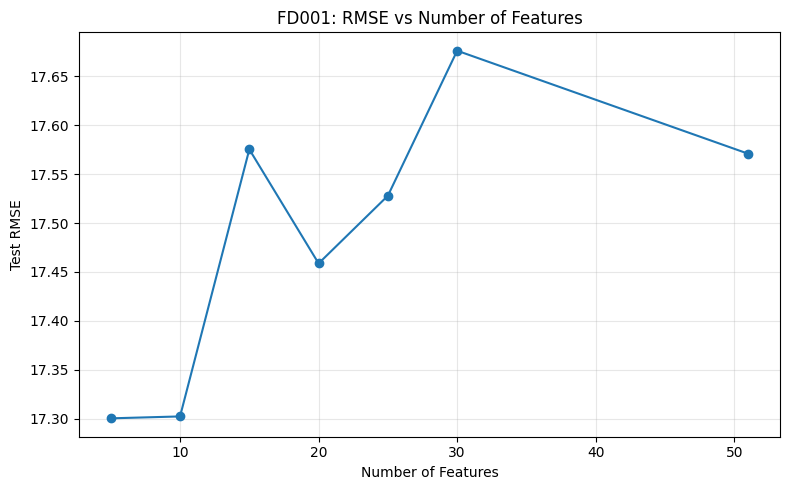

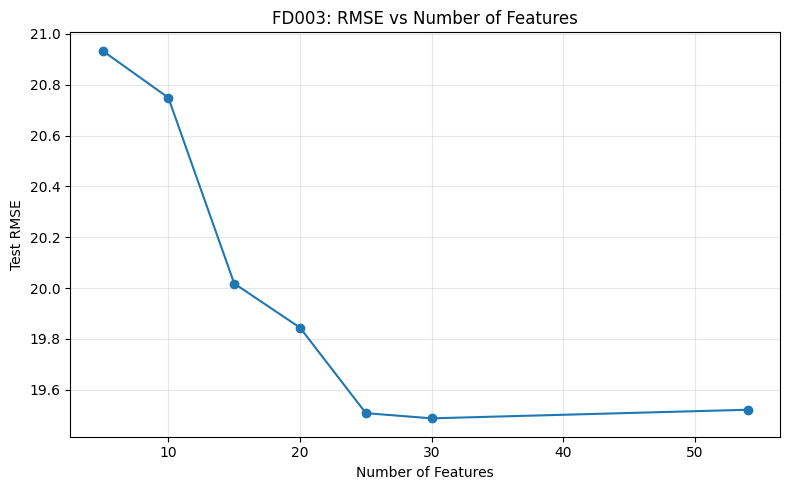

In [46]:
# ============================================================
# CELL 40 — ACCURACY VS FEATURE COUNT
# ============================================================

for subset in ["FD001", "FD003"]:

    df = pruning_results[
        subset
    ]["results"]

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        df["n_features"],
        df["rmse"],
        marker="o"
    )

    plt.xlabel(
        "Number of Features"
    )

    plt.ylabel(
        "Test RMSE"
    )

    plt.title(
        f"{subset}: RMSE vs Number of Features"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR /
        f"{subset}_rmse_vs_features.png",
        dpi=150
    )

    plt.show()

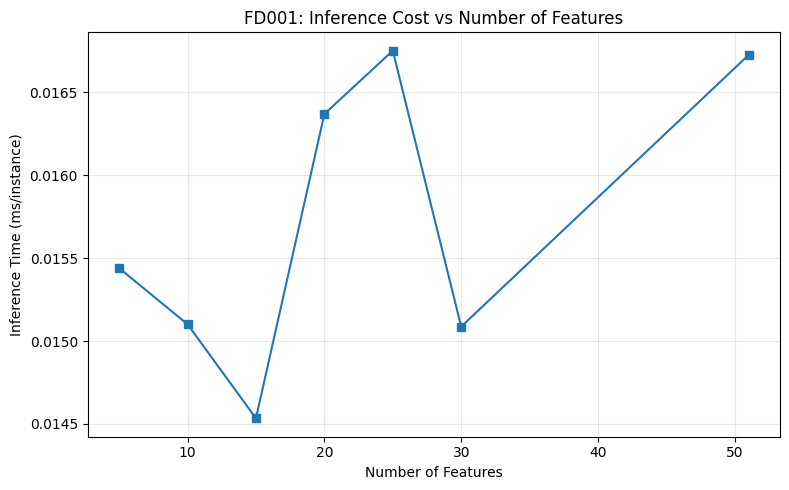

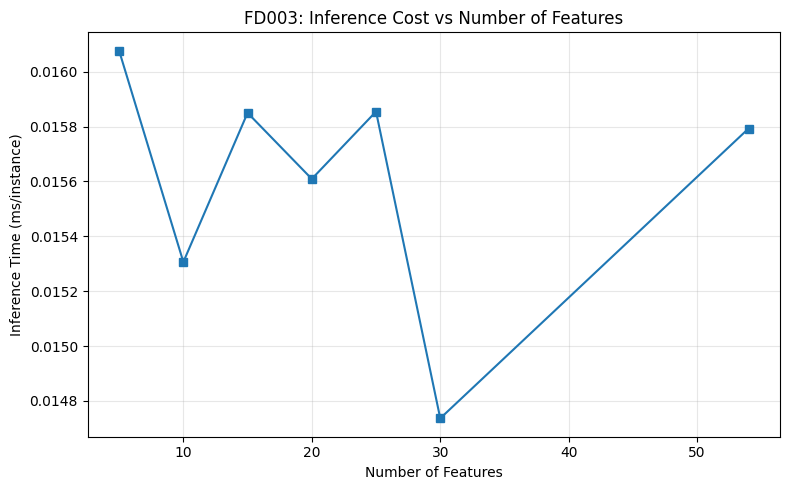

In [47]:
# ============================================================
# CELL 41 — INFERENCE TIME VS FEATURE COUNT
# ============================================================

for subset in ["FD001", "FD003"]:

    df = pruning_results[
        subset
    ]["results"]

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        df["n_features"],
        df["infer_time_ms_per_instance"],
        marker="s"
    )

    plt.xlabel(
        "Number of Features"
    )

    plt.ylabel(
        "Inference Time (ms/instance)"
    )

    plt.title(
        f"{subset}: Inference Cost vs Number of Features"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR /
        f"{subset}_inference_vs_features.png",
        dpi=150
    )

    plt.show()

In [48]:
# ============================================================
# CELL 42 — DISPLAY TRADE-OFF RESULTS
# ============================================================

for subset in ["FD001", "FD003"]:

    print("\n")
    print("=" * 70)
    print(f"{subset} — FEATURE PRUNING RESULTS")
    print("=" * 70)

    display(
        pruning_results[
            subset
        ]["results"]
    )



FD001 — FEATURE PRUNING RESULTS


,n_features,rmse,train_time_s,infer_time_ms_per_instance
0,5,17.300272,0.093812,0.015440
1,10,17.302225,0.122468,0.015101
2,15,17.575303,0.152880,0.014534
3,20,17.458682,0.186934,0.016370
4,25,17.527917,0.235721,0.016751
5,30,17.676204,0.254135,0.015087
6,51,17.570887,0.403990,0.016725




FD003 — FEATURE PRUNING RESULTS


,n_features,rmse,train_time_s,infer_time_ms_per_instance
0,5,20.933542,0.104427,0.016077
1,10,20.748625,0.136738,0.015306
2,15,20.017880,0.164470,0.015850
3,20,19.844032,0.195024,0.015609
4,25,19.507866,0.233472,0.015855
5,30,19.487497,0.271191,0.014737
6,54,19.521260,0.437475,0.015793
